<a href="https://colab.research.google.com/github/ipd0828/Hakaton-MIFI/blob/main/MIFI_DL_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Свертки в Keras

Будем использовать Fashion MNIST

In [1]:
!pip install -q tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 574.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt
%matplotlib inline
import tensorflow as tf
print("We're using TF", tf.__version__)
import tensorflow.keras as keras
import tensorflow.keras.models as M
import tensorflow.keras.layers as L
import tensorflow.keras.backend as K
import pandas as pd

We're using TF 2.19.0


In [3]:
# Проверяем что у нас работает GPU
tf.test.gpu_device_name()

''

In [4]:
#GPU count and name
!nvidia-smi -L

/bin/bash: line 1: nvidia-smi: command not found


# Загрузим данные

Классы:
```
0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot
```




In [5]:
(x_train, y_train), (x_val, y_val) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
print(x_train.shape)
print(x_val.shape)
print (y_train[:10])
print (y_val[:10])

(60000, 28, 28)
(10000, 28, 28)
[9 0 0 3 0 2 7 2 5 5]
[9 2 1 1 6 1 4 6 5 7]


Пример кусочка картинки:


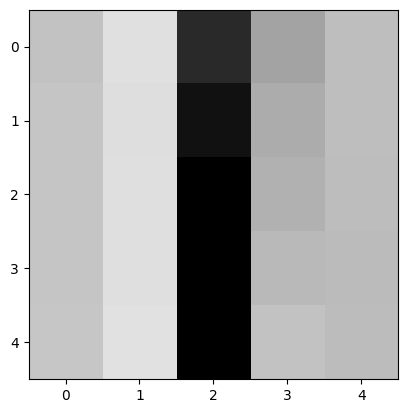

Пример картинки:


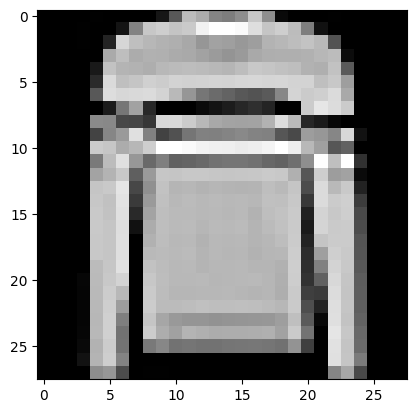

y_train [shape (60000,)] 10 примеров:
 [9 0 0 3 0 2 7 2 5 5]


In [7]:
x_train_image = np.tile(x_train[5, :, :].reshape((28, 28))[:, :, np.newaxis], (1, 1, 3))
print("Пример кусочка картинки:")
plt.imshow(x_train_image[15:20, 5:10], cmap="Greys")
plt.show()
print("Пример картинки:")
plt.imshow(x_train_image, cmap="Greys")
plt.show()
print("y_train [shape %s] 10 примеров:\n" % (str(y_train.shape)), y_train[:10])

In [8]:
# one-hot encode для ответов
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_val_oh = keras.utils.to_categorical(y_val, 10)

print(y_train_oh.shape)
print(y_train_oh[:5], y_train[:5])

(60000, 10)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] [9 0 0 3 0]


# Собираем модель

Будем как и в предыдущем модуле минимизировать кросс-энтропию.

In [9]:
K.clear_session()

# в этот раз используем картинку как вход без вытягивания в вектор!

model = M.Sequential()
model.add(L.Conv2D(16, kernel_size=3, strides=1, padding='same', input_shape=(28, 28, 1)))
model.add(L.MaxPool2D())
model.add(L.Conv2D(32, kernel_size=3, strides=1, padding='same'))
model.add(L.MaxPool2D())
model.add(L.Conv2D(64, kernel_size=3, strides=1, padding='same'))
model.add(L.MaxPool2D())
model.add(L.Flatten())
model.add(L.Dense(10, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,066 (113.54 KB)

 Trainable params: 29,066 (113.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    loss='categorical_crossentropy',  # минимизируем кросс-энтропию
    optimizer='adam',  # так будет быстрее, позже узнаем что это :)
    metrics=['accuracy']  # выводим процент правильных ответов
)

In [12]:
# центрируем и нормируем, так сети будет проще учиться (позже узнаем почему :)
x_train_float = x_train.astype(np.float32) / 255 - 0.5
x_val_float = x_val.astype(np.float32) / 255 - 0.5

In [13]:
model.fit(
    x_train_float[:, :, :, np.newaxis],
    y_train_oh,
    batch_size=32,
    epochs=5,
    validation_data=(x_val_float[:, :, :, np.newaxis], y_val_oh)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.7658 - loss: 0.6521 - val_accuracy: 0.8618 - val_loss: 0.4010
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.8837 - loss: 0.3305 - val_accuracy: 0.8875 - val_loss: 0.3124
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9001 - loss: 0.2823 - val_accuracy: 0.8962 - val_loss: 0.2958
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9105 - loss: 0.2499 - val_accuracy: 0.8944 - val_loss: 0.2953
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9175 - loss: 0.2308 - val_accuracy: 0.8943 - val_loss: 0.3026


In [14]:
# Получение предсказаний вероятностей для каждого класса
y_pred_probs = model.predict(x_val_float[:, :, :, np.newaxis])

# Когда модель имеет softmax на выходе, можно получить предсказанные классы:
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Если y_val_oh one-hot encoded, преобразуем в метки классов для сравнения
y_true_classes = np.argmax(y_val_oh, axis=1)

# Вывод первых 10 предсказаний для примера
print("Первые 10 предсказаний:")
for i in range(10):
    print(f"Пример {i+1}: Предсказанный класс = {y_pred_classes[i]}, Истинный класс = {y_true_classes[i]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Первые 10 предсказаний:
Пример 1: Предсказанный класс = 9, Истинный класс = 9
Пример 2: Предсказанный класс = 2, Истинный класс = 2
Пример 3: Предсказанный класс = 1, Истинный класс = 1
Пример 4: Предсказанный класс = 1, Истинный класс = 1
Пример 5: Предсказанный класс = 6, Истинный класс = 6
Пример 6: Предсказанный класс = 1, Истинный класс = 1
Пример 7: Предсказанный класс = 4, Истинный класс = 4
Пример 8: Предсказанный класс = 6, Истинный класс = 6
Пример 9: Предсказанный класс = 5, Истинный класс = 5
Пример 10: Предсказанный класс = 7, Истинный класс = 7


In [16]:
# Выберем одну картинку из валидационного набора
sample_image = x_val_float[0][np.newaxis, :, :, np.newaxis]

# Получаем предсказание
prediction = model.predict(sample_image)
predicted_class = np.argmax(prediction)

print(f"Предсказанный класс для примера: {predicted_class}")
print(f"Вероятности по классам: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Предсказанный класс для примера: 9
Вероятности по классам: [[1.6688043e-06 7.7533485e-08 1.5435244e-06 3.3336389e-07 1.1718673e-06
  7.9876435e-04 6.8647969e-06 1.0474522e-02 1.0079110e-04 9.8861432e-01]]


In [17]:
# Точность на всем валидационном наборе
test_loss, test_acc = model.evaluate(x_val_float[:, :, :, np.newaxis], y_val_oh)
print(f"\nТочность на валидационном наборе: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8963 - loss: 0.3060

Точность на валидационном наборе: 0.8943


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


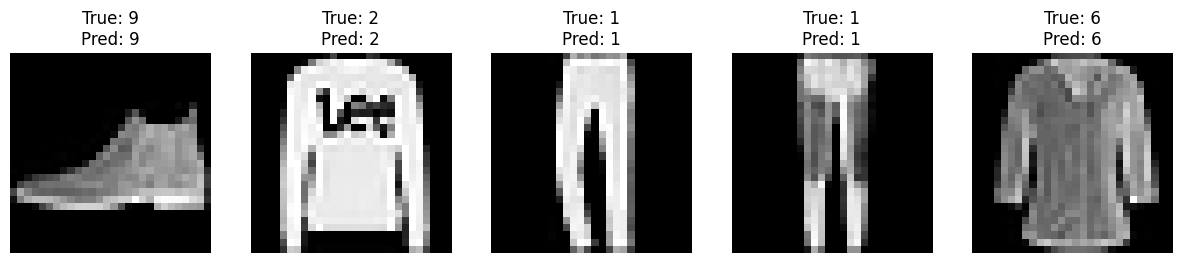

In [18]:

# Выбираем несколько примеров для визуализации
num_samples = 5
plt.figure(figsize=(15, 3))
for i in range(num_samples):
    # Подготовка изображения
    img = x_val_float[i][:, :, np.newaxis][np.newaxis, ...]

    # Предсказание
    pred = model.predict(img)
    pred_class = np.argmax(pred)
    true_class = np.argmax(y_val_oh[i])

    # Визуализация
    plt.subplot(1, num_samples, i+1)
    plt.imshow(x_val_float[i], cmap='gray')
    plt.title(f"True: {true_class}\nPred: {pred_class}")
    plt.axis('off')
plt.show()

In [23]:
# Загружаем из kaggle наш тестовый набор для
# построения прогноза
x_test_1 = pd.read_csv('/content/fmnist_test_1.csv')
# Удаляем лишнее
x_test_1_drop = x_test_1.drop(['Id'], axis=1)


In [36]:
# Делаем решейп под формат обученной модели
x_test_1_drop = x_test_1_drop.values.reshape(-1, 28, 28)

In [37]:
# Стандартизируем
x_test_1_norm = x_test_1_drop.astype(np.float32) / 255 - 0.5

In [38]:
# Получение предсказаний вероятностей для каждого класса
y_pred_probs = model.predict(x_test_1_norm[:, :, :, np.newaxis])

# Получаем предсказанные классы:
y_pred_classes = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [49]:
# Формируем сабмит
df_submit = pd.DataFrame(y_pred_classes)
df_submit = df_submit.reset_index()
df_submit.columns = ['Id', 'label']

In [53]:
df_submit.head()

,Id,label
0,0,0
1,1,1
2,2,2
3,3,6
4,4,3


In [54]:
# Сохраняем
df_submit.to_csv('submission_2.csv', index=False)

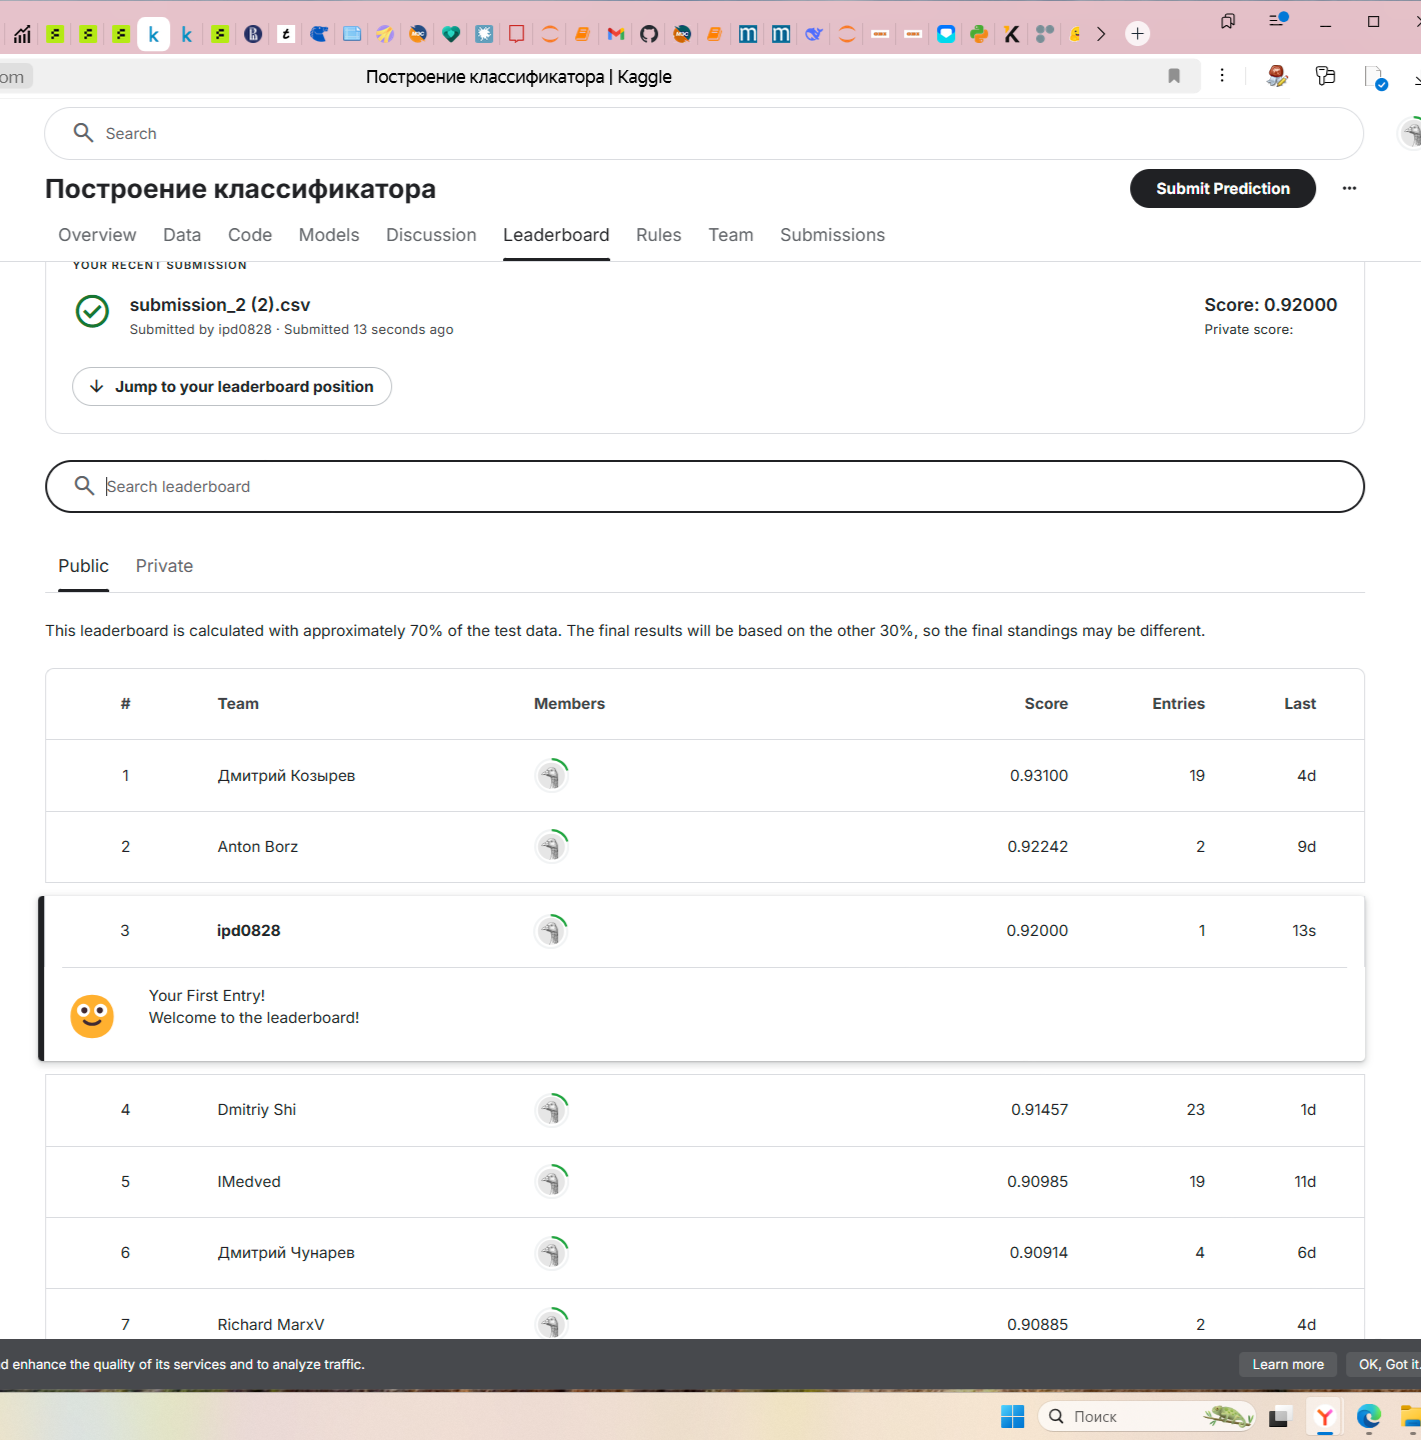